# Previsão de Perturbação Mental em Idosos — Benchmark de Modelos Tradicionais

## Objetivo

Este notebook tem como objetivo prever a **probabilidade de perturbação mental** (`probability_mental_disorder`) em idosos a partir de variáveis sociodemográficas, clínicas e de estilo de vida, utilizando vários modelos de machine learning tradicionais.

A variável `probability_mental_disorder` é usada exclusivamente como **ground truth de avaliação** e não é usada como feature de treino.

## Dataset

- **Ficheiro:** `Dataset_Idosos.xlsx`
- **Dimensão:** 586 participantes × 17 variáveis
- **Natureza:** Dataset sintético gerado para fins académicos, os padrões presentes podem não reflectir a complexidade e variabilidade de uma população real de idosos
- **Variável alvo:** `probability_mental_disorder` (contínua, 0–1)

## Estratégia de Split e Validação

Com apenas 586 observações e modelos tradicionais, a abordagem mais robusta é:

- **80% treino / 20% teste** (holdout final)
- **Cross-validation com 5 folds** no conjunto de treino, para seleção e avaliação de hiperparâmetros


> Nota: Este notebook foi desenvolvido numa fase exploratória inicial
com um dataset reduzido. O pipeline final utiliza o dataset completo
(~3915 participantes) nos notebooks seguintes.

---
## 1. Importações e Configuração

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, cross_val_score, KFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Modelos
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

# Métricas
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# Reproducibilidade
SEED = 42
np.random.seed(SEED)

# Estilo de plots
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = 'muted'

print('✅ Dependências carregadas com sucesso.')

✅ Dependências carregadas com sucesso.


---
## 2. Carregamento e Inspeção dos Dados

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_excel('/content/drive/MyDrive/IACD/Projeto/Dataset_Idosos.xlsx')

print(f'Dimensão: {df.shape[0]} linhas × {df.shape[1]} colunas')
print()
df.head()

Dimensão: 586 linhas × 17 colunas



,participant_id,age,gender,education_years,monthly_income,marital_status,living_situation,comorbidities_count,physical_activity_days_per_week,physical_activity_minutes_per_session,physical_activity_total_minutes_week,physical_activity_type,physical_activity_intensity,sleep_hours,phq9_total,gad7_total,probability_mental_disorder
0,1,72,2,8,4250.50,2,2,3.0,4.0,38.0,152.0,1.0,1.0,6.8,12.0,8.0,0.42
1,2,68,1,10,5100.75,2,2,2.0,5.0,42.0,210.0,1.0,2.0,7.2,9.0,6.0,0.28
2,3,81,2,6,3200.25,4,4,5.0,1.0,25.0,25.0,2.0,1.0,6.5,16.0,11.0,0.65
3,4,75,1,12,4800.00,2,2,1.0,6.0,35.0,210.0,4.0,2.0,7.0,8.0,5.0,0.22
4,5,66,2,5,3500.50,1,3,2.0,3.0,30.0,90.0,1.0,1.0,7.5,11.0,7.0,0.35


In [ ]:
# Tipos de dados e valores nulos
info = pd.DataFrame({
    'dtype': df.dtypes,
    'não_nulos': df.notna().sum(),
    'nulos': df.isna().sum(),
    '% nulos': (df.isna().sum() / len(df) * 100).round(2)
})
print(info.to_string())

                                         dtype  não_nulos  nulos  % nulos
participant_id                           int64        586      0     0.00
age                                      int64        586      0     0.00
gender                                   int64        586      0     0.00
education_years                          int64        586      0     0.00
monthly_income                         float64        586      0     0.00
marital_status                           int64        586      0     0.00
living_situation                         int64        586      0     0.00
comorbidities_count                    float64        585      1     0.17
physical_activity_days_per_week        float64        585      1     0.17
physical_activity_minutes_per_session  float64        585      1     0.17
physical_activity_total_minutes_week   float64        584      2     0.34
physical_activity_type                 float64        584      2     0.34
physical_activity_intensity           

In [ ]:
# Estatísticas descritivas
df.describe().round(3)

,participant_id,age,gender,education_years,monthly_income,marital_status,living_situation,comorbidities_count,physical_activity_days_per_week,physical_activity_minutes_per_session,physical_activity_total_minutes_week,physical_activity_type,physical_activity_intensity,sleep_hours,phq9_total,gad7_total,probability_mental_disorder
count,586.000,586.000,586.00,586.000,586.000,586.000,586.000,585.000,585.000,585.000,584.000,584.000,584.000,584.000,584.000,584.000,584.000
mean,293.500,75.254,1.52,9.009,2661.715,2.655,2.331,2.579,3.309,28.412,126.630,1.524,1.262,6.565,10.455,7.774,0.470
std,169.308,6.043,0.50,3.029,1239.739,0.947,0.907,1.393,2.287,16.025,103.924,1.263,0.760,0.940,5.335,4.206,0.259
min,1.000,64.000,1.00,2.000,350.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,3.500,1.000,1.000,0.030
25%,147.250,70.000,1.00,7.000,1650.758,2.000,2.000,2.000,1.000,20.000,25.000,1.000,1.000,6.000,6.000,5.000,0.250
50%,293.500,75.000,2.00,9.000,2665.385,2.000,2.000,2.000,4.000,33.000,122.500,1.000,1.000,6.900,9.000,7.000,0.420
75%,439.750,80.000,2.00,11.000,3600.500,4.000,3.000,3.000,5.000,40.000,201.000,3.000,2.000,7.300,14.000,10.000,0.700
max,586.000,90.000,2.00,16.000,5100.750,4.000,4.000,7.000,7.000,60.000,420.000,5.000,3.000,8.000,26.000,21.000,1.000


### Observações iniciais

- Existem **alguns valores nulos** (máx. 2 por coluna) — percentagem residual, será imputada com a mediana.
- As variáveis categóricas (`gender`, `marital_status`, `living_situation`, `physical_activity_type`, `physical_activity_intensity`) estão codificadas numericamente.
- A variável alvo `probability_mental_disorder` varia entre 0.03 e 1.00, com média ≈ 0.47.
- `participant_id` é apenas um identificador e será removido antes do treino.

---
## 3. Pré-processamento

In [ ]:
# Remover identificador e separar features do alvo
TARGET = 'probability_mental_disorder'
DROP_COLS = ['participant_id']

df_clean = df.dropna(subset=[TARGET]).copy()  # Remover os 2 casos sem target
print(f'Linhas após remover nulos no target: {len(df_clean)}')

X = df_clean.drop(columns=DROP_COLS + [TARGET])
y = df_clean[TARGET]

print(f'Features: {X.shape[1]}')
print(f'Feature names: {X.columns.tolist()}')

Linhas após remover nulos no target: 584
Features: 15
Feature names: ['age', 'gender', 'education_years', 'monthly_income', 'marital_status', 'living_situation', 'comorbidities_count', 'physical_activity_days_per_week', 'physical_activity_minutes_per_session', 'physical_activity_total_minutes_week', 'physical_activity_type', 'physical_activity_intensity', 'sleep_hours', 'phq9_total', 'gad7_total']


In [ ]:
# Split treino (80%) / teste (20%) — holdout final
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

print(f'Treino:  {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Teste:   {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.1f}%)')
print()
print(f'y_train — média: {y_train.mean():.3f}, std: {y_train.std():.3f}')
print(f'y_test  — média: {y_test.mean():.3f}, std: {y_test.std():.3f}')

Treino:  467 amostras (80.0%)
Teste:   117 amostras (20.0%)

y_train — média: 0.474, std: 0.262
y_test  — média: 0.455, std: 0.249


In [ ]:
# Pipeline base: imputação da mediana + standardização
# Cada modelo usará este pipeline para evitar data leakage

def make_pipeline(model):
    """Cria um pipeline com imputação de mediana, standardização e o modelo."""
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', model)
    ])

# Cross-validation setup (5-fold, shuffled)
CV = KFold(n_splits=5, shuffle=True, random_state=SEED)

print('✅ Pipeline e CV configurados.')

✅ Pipeline e CV configurados.


---
## 4. Treino e Avaliação dos Modelos

Para cada modelo:
1. Treino com **5-fold cross-validation** no conjunto de treino → avaliação interna robusta
2. Treino no conjunto de treino completo
3. Avaliação no **conjunto de teste holdout** (tocado apenas uma vez no final)

**Métricas utilizadas:**
- **MAE** (Mean Absolute Error) — erro médio absoluto, interpretável na escala do alvo
- **RMSE** (Root Mean Squared Error) — penaliza erros grandes
- **R²** — proporção da variância explicada (1.0 = perfeito, 0 = baseline)

In [ ]:
def evaluate_model(name, pipeline, X_train, y_train, X_test, y_test, cv):
    """
    Avalia um modelo com cross-validation e no conjunto de teste.
    Retorna um dicionário com as métricas.
    """
    # Cross-validation no treino
    cv_r2   = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='r2')
    cv_mae  = -cross_val_score(pipeline, X_train, y_train, cv=cv,
                                scoring='neg_mean_absolute_error')
    cv_rmse = -cross_val_score(pipeline, X_train, y_train, cv=cv,
                                scoring='neg_root_mean_squared_error')

    # Treino final e avaliação no teste
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    # Clipar previsões ao intervalo [0, 1] (probabilidades)
    y_pred = np.clip(y_pred, 0, 1)

    test_mae  = mean_absolute_error(y_test, y_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    test_r2   = r2_score(y_test, y_pred)

    return {
        'Modelo': name,
        'CV R² (média)': cv_r2.mean(),
        'CV R² (std)': cv_r2.std(),
        'CV MAE (média)': cv_mae.mean(),
        'CV RMSE (média)': cv_rmse.mean(),
        'Teste MAE': test_mae,
        'Teste RMSE': test_rmse,
        'Teste R²': test_r2,
        'y_pred': y_pred
    }

print('✅ Função de avaliação definida.')

✅ Função de avaliação definida.


### 4.1 Regressão Linear (Baseline)

In [ ]:
results = []
predictions = {}

# --- Regressão Linear ---
lr_pipe = make_pipeline(LinearRegression())
r = evaluate_model('Regressão Linear', lr_pipe, X_train, y_train, X_test, y_test, CV)
predictions['Regressão Linear'] = r.pop('y_pred')
results.append(r)
print(f"Regressão Linear | CV R²: {r['CV R² (média)']:.4f} ± {r['CV R² (std)']:.4f} | Teste R²: {r['Teste R²']:.4f} | Teste MAE: {r['Teste MAE']:.4f}")

Regressão Linear | CV R²: 0.8854 ± 0.0132 | Teste R²: 0.8541 | Teste MAE: 0.0746


### 4.2 Ridge (Regularização L2)

In [ ]:
ridge_pipe = make_pipeline(Ridge(alpha=1.0))
r = evaluate_model('Ridge', ridge_pipe, X_train, y_train, X_test, y_test, CV)
predictions['Ridge'] = r.pop('y_pred')
results.append(r)
print(f"Ridge            | CV R²: {r['CV R² (média)']:.4f} ± {r['CV R² (std)']:.4f} | Teste R²: {r['Teste R²']:.4f} | Teste MAE: {r['Teste MAE']:.4f}")

Ridge            | CV R²: 0.8851 ± 0.0134 | Teste R²: 0.8543 | Teste MAE: 0.0742


### 4.3 Lasso (Regularização L1)

In [ ]:
lasso_pipe = make_pipeline(Lasso(alpha=0.001))
r = evaluate_model('Lasso', lasso_pipe, X_train, y_train, X_test, y_test, CV)
predictions['Lasso'] = r.pop('y_pred')
results.append(r)
print(f"Lasso            | CV R²: {r['CV R² (média)']:.4f} ± {r['CV R² (std)']:.4f} | Teste R²: {r['Teste R²']:.4f} | Teste MAE: {r['Teste MAE']:.4f}")

Lasso            | CV R²: 0.8858 ± 0.0134 | Teste R²: 0.8581 | Teste MAE: 0.0735


### 4.4 ElasticNet (L1 + L2)

In [ ]:
en_pipe = make_pipeline(ElasticNet(alpha=0.001, l1_ratio=0.5))
r = evaluate_model('ElasticNet', en_pipe, X_train, y_train, X_test, y_test, CV)
predictions['ElasticNet'] = r.pop('y_pred')
results.append(r)
print(f"ElasticNet       | CV R²: {r['CV R² (média)']:.4f} ± {r['CV R² (std)']:.4f} | Teste R²: {r['Teste R²']:.4f} | Teste MAE: {r['Teste MAE']:.4f}")

ElasticNet       | CV R²: 0.8860 ± 0.0134 | Teste R²: 0.8566 | Teste MAE: 0.0738


### 4.5 K-Nearest Neighbours (KNN)

In [ ]:
knn_pipe = make_pipeline(KNeighborsRegressor(n_neighbors=7))
r = evaluate_model('KNN', knn_pipe, X_train, y_train, X_test, y_test, CV)
predictions['KNN'] = r.pop('y_pred')
results.append(r)
print(f"KNN              | CV R²: {r['CV R² (média)']:.4f} ± {r['CV R² (std)']:.4f} | Teste R²: {r['Teste R²']:.4f} | Teste MAE: {r['Teste MAE']:.4f}")

KNN              | CV R²: 0.7985 ± 0.0290 | Teste R²: 0.7408 | Teste MAE: 0.0820


### 4.6 Árvore de Decisão

In [ ]:
dt_pipe = make_pipeline(DecisionTreeRegressor(max_depth=5, min_samples_leaf=10,
                                               random_state=SEED))
r = evaluate_model('Árvore de Decisão', dt_pipe, X_train, y_train, X_test, y_test, CV)
predictions['Árvore de Decisão'] = r.pop('y_pred')
results.append(r)
print(f"Árvore de Decisão| CV R²: {r['CV R² (média)']:.4f} ± {r['CV R² (std)']:.4f} | Teste R²: {r['Teste R²']:.4f} | Teste MAE: {r['Teste MAE']:.4f}")

Árvore de Decisão| CV R²: 0.8561 ± 0.0255 | Teste R²: 0.8423 | Teste MAE: 0.0791


### 4.7 Support Vector Regression (SVR)

In [ ]:
svr_pipe = make_pipeline(SVR(kernel='rbf', C=1.0, epsilon=0.05))
r = evaluate_model('SVR (RBF)', svr_pipe, X_train, y_train, X_test, y_test, CV)
predictions['SVR (RBF)'] = r.pop('y_pred')
results.append(r)
print(f"SVR (RBF)        | CV R²: {r['CV R² (média)']:.4f} ± {r['CV R² (std)']:.4f} | Teste R²: {r['Teste R²']:.4f} | Teste MAE: {r['Teste MAE']:.4f}")

SVR (RBF)        | CV R²: 0.9090 ± 0.0159 | Teste R²: 0.8931 | Teste MAE: 0.0580


### 4.8 Random Forest

In [ ]:
rf_pipe = make_pipeline(RandomForestRegressor(n_estimators=200, max_depth=6,
                                              min_samples_leaf=5, random_state=SEED,
                                              n_jobs=-1))
r = evaluate_model('Random Forest', rf_pipe, X_train, y_train, X_test, y_test, CV)
predictions['Random Forest'] = r.pop('y_pred')
results.append(r)
print(f"Random Forest    | CV R²: {r['CV R² (média)']:.4f} ± {r['CV R² (std)']:.4f} | Teste R²: {r['Teste R²']:.4f} | Teste MAE: {r['Teste MAE']:.4f}")

Random Forest    | CV R²: 0.8966 ± 0.0171 | Teste R²: 0.8843 | Teste MAE: 0.0608


### 4.9 Extra Trees

In [ ]:
et_pipe = make_pipeline(ExtraTreesRegressor(n_estimators=200, max_depth=6,
                                            min_samples_leaf=5, random_state=SEED,
                                            n_jobs=-1))
r = evaluate_model('Extra Trees', et_pipe, X_train, y_train, X_test, y_test, CV)
predictions['Extra Trees'] = r.pop('y_pred')
results.append(r)
print(f"Extra Trees      | CV R²: {r['CV R² (média)']:.4f} ± {r['CV R² (std)']:.4f} | Teste R²: {r['Teste R²']:.4f} | Teste MAE: {r['Teste MAE']:.4f}")

Extra Trees      | CV R²: 0.8936 ± 0.0177 | Teste R²: 0.8723 | Teste MAE: 0.0682


### 4.10 Gradient Boosting

In [ ]:
gb_pipe = make_pipeline(GradientBoostingRegressor(n_estimators=200, max_depth=3,
                                                   learning_rate=0.05, subsample=0.8,
                                                   random_state=SEED))
r = evaluate_model('Gradient Boosting', gb_pipe, X_train, y_train, X_test, y_test, CV)
predictions['Gradient Boosting'] = r.pop('y_pred')
results.append(r)
print(f"Gradient Boosting| CV R²: {r['CV R² (média)']:.4f} ± {r['CV R² (std)']:.4f} | Teste R²: {r['Teste R²']:.4f} | Teste MAE: {r['Teste MAE']:.4f}")

Gradient Boosting| CV R²: 0.9120 ± 0.0156 | Teste R²: 0.9069 | Teste MAE: 0.0558


### 4.11 MLP (Rede Neural Simples)

In [ ]:
mlp_pipe = make_pipeline(MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu',
                                       alpha=0.01, max_iter=500, random_state=SEED,
                                       early_stopping=True, validation_fraction=0.1))
r = evaluate_model('MLP', mlp_pipe, X_train, y_train, X_test, y_test, CV)
predictions['MLP'] = r.pop('y_pred')
results.append(r)
print(f"MLP              | CV R²: {r['CV R² (média)']:.4f} ± {r['CV R² (std)']:.4f} | Teste R²: {r['Teste R²']:.4f} | Teste MAE: {r['Teste MAE']:.4f}")

MLP              | CV R²: 0.8656 ± 0.0254 | Teste R²: 0.8477 | Teste MAE: 0.0710


---
## 5. Comparação dos Resultados

In [ ]:
# Tabela de resultados
results_df = pd.DataFrame(results).set_index('Modelo')
results_df = results_df.sort_values('Teste R²', ascending=False)

display_df = results_df[['CV R² (média)', 'CV R² (std)', 'CV MAE (média)',
                          'Teste R²', 'Teste MAE', 'Teste RMSE']].round(4)

# Estilo com destaque para o melhor modelo
styled = display_df.style\
    .background_gradient(subset=['Teste R²'], cmap='RdYlGn')\
    .background_gradient(subset=['Teste MAE', 'Teste RMSE'], cmap='RdYlGn_r')\
    .format('{:.4f}')\
    .set_caption('📊 Comparação de Modelos — ordenado por Teste R² (descendente)')

display(styled)

,CV R² (média),CV R² (std),CV MAE (média),Teste R²,Teste MAE,Teste RMSE
Modelo,,,,,,
Gradient Boosting,0.9120,0.0156,0.0578,0.9069,0.0558,0.0756
SVR (RBF),0.9090,0.0159,0.0607,0.8931,0.0580,0.0810
Random Forest,0.8966,0.0171,0.0643,0.8843,0.0608,0.0843
Extra Trees,0.8936,0.0177,0.0675,0.8723,0.0682,0.0886
Lasso,0.8858,0.0134,0.0713,0.8581,0.0735,0.0934
ElasticNet,0.8860,0.0134,0.0710,0.8566,0.0738,0.0938
Ridge,0.8851,0.0134,0.0709,0.8543,0.0742,0.0946
Regressão Linear,0.8854,0.0132,0.0710,0.8541,0.0746,0.0947
MLP,0.8656,0.0254,0.0724,0.8477,0.0710,0.0967


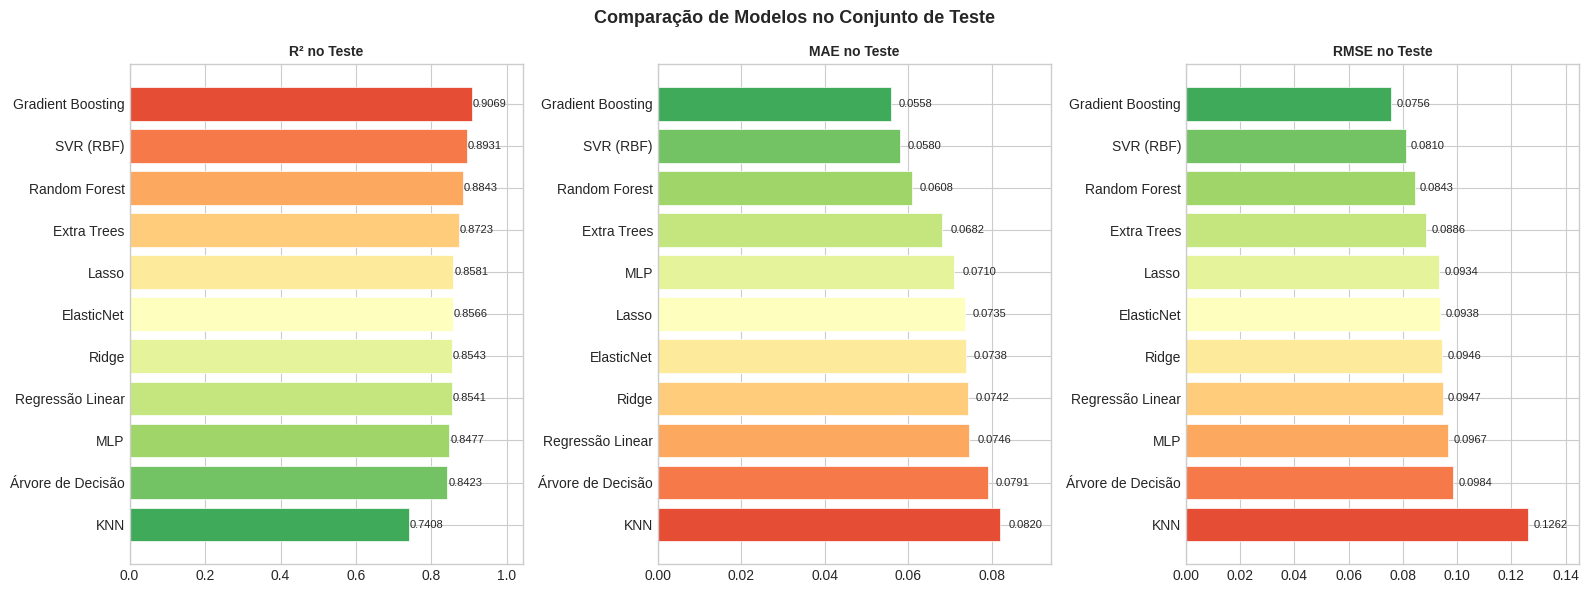

In [ ]:
# Gráfico de barras comparativo — Teste R²
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

metrics = ['Teste R²', 'Teste MAE', 'Teste RMSE']
titles  = ['R² no Teste', 'MAE no Teste', 'RMSE no Teste']
cmaps   = [True, False, False]  # True = maior é melhor

for ax, metric, title, higher_better in zip(axes, metrics, titles, cmaps):
    vals = results_df[metric].sort_values(ascending=not higher_better)
    colors_bar = plt.cm.RdYlGn(
        np.linspace(0.15, 0.85, len(vals)) if higher_better
        else np.linspace(0.85, 0.15, len(vals))
    )
    bars = ax.barh(vals.index[::-1], vals.values[::-1], color=colors_bar[::-1],
                   edgecolor='white', linewidth=0.5)
    ax.set_title(title, fontweight='bold', fontsize=10)
    for bar, val in zip(bars, vals.values[::-1]):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)
    ax.set_xlim(0, vals.max() * 1.15)

plt.suptitle('Comparação de Modelos no Conjunto de Teste', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

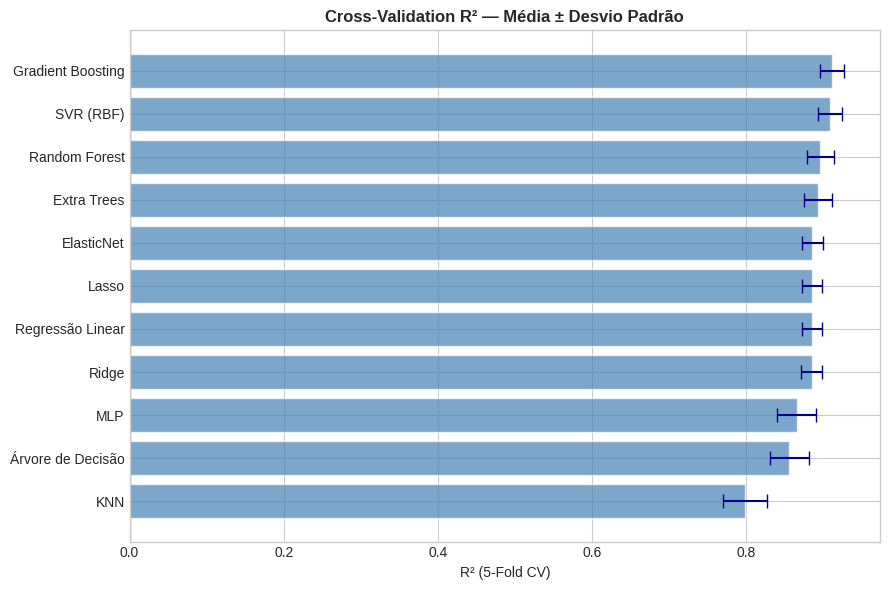

In [ ]:
# CV R² com intervalo de confiança (mean ± std)
cv_data = results_df[['CV R² (média)', 'CV R² (std)']].sort_values('CV R² (média)', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
y_pos = range(len(cv_data))
ax.barh(y_pos, cv_data['CV R² (média)'], xerr=cv_data['CV R² (std)'],
        color='steelblue', alpha=0.7, ecolor='darkblue', capsize=5, edgecolor='white')
ax.set_yticks(y_pos)
ax.set_yticklabels(cv_data.index)
ax.set_xlabel('R² (5-Fold CV)')
ax.set_title('Cross-Validation R² — Média ± Desvio Padrão', fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

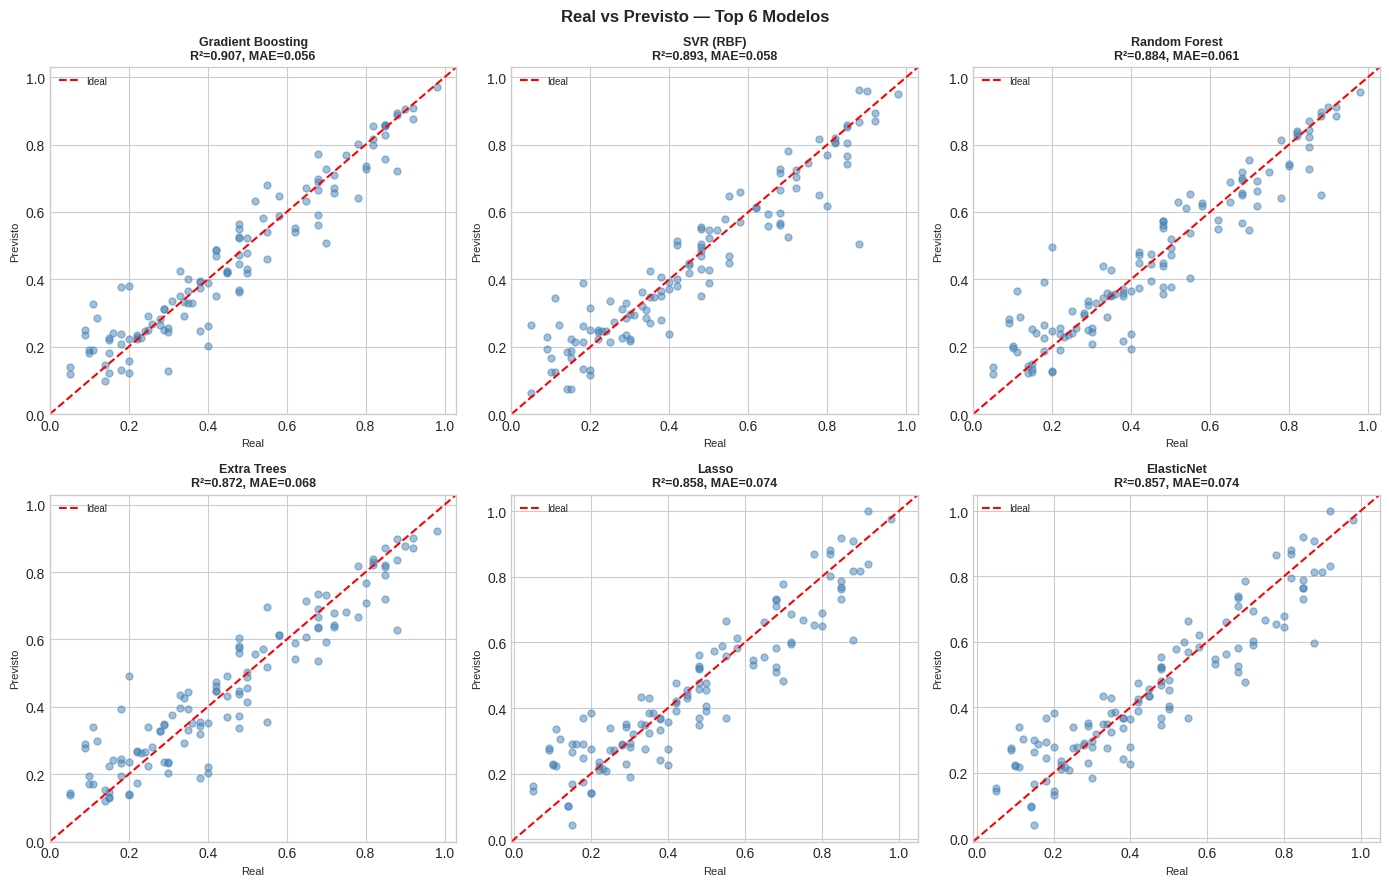

In [ ]:
# Scatter plots: valores reais vs previstos (por modelo)
top_models = results_df['Teste R²'].sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

y_test_arr = y_test.values

for i, model_name in enumerate(top_models):
    y_pred = predictions[model_name]
    r2 = r2_score(y_test_arr, y_pred)
    mae = mean_absolute_error(y_test_arr, y_pred)

    axes[i].scatter(y_test_arr, y_pred, alpha=0.5, s=25, color='steelblue')
    lims = [min(y_test_arr.min(), y_pred.min()) - 0.05,
            max(y_test_arr.max(), y_pred.max()) + 0.05]
    axes[i].plot(lims, lims, 'r--', linewidth=1.5, label='Ideal')
    axes[i].set_xlim(lims); axes[i].set_ylim(lims)
    axes[i].set_title(f'{model_name}\nR²={r2:.3f}, MAE={mae:.3f}',
                      fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Real', fontsize=8)
    axes[i].set_ylabel('Previsto', fontsize=8)
    axes[i].legend(fontsize=7)

plt.suptitle('Real vs Previsto — Top 6 Modelos', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

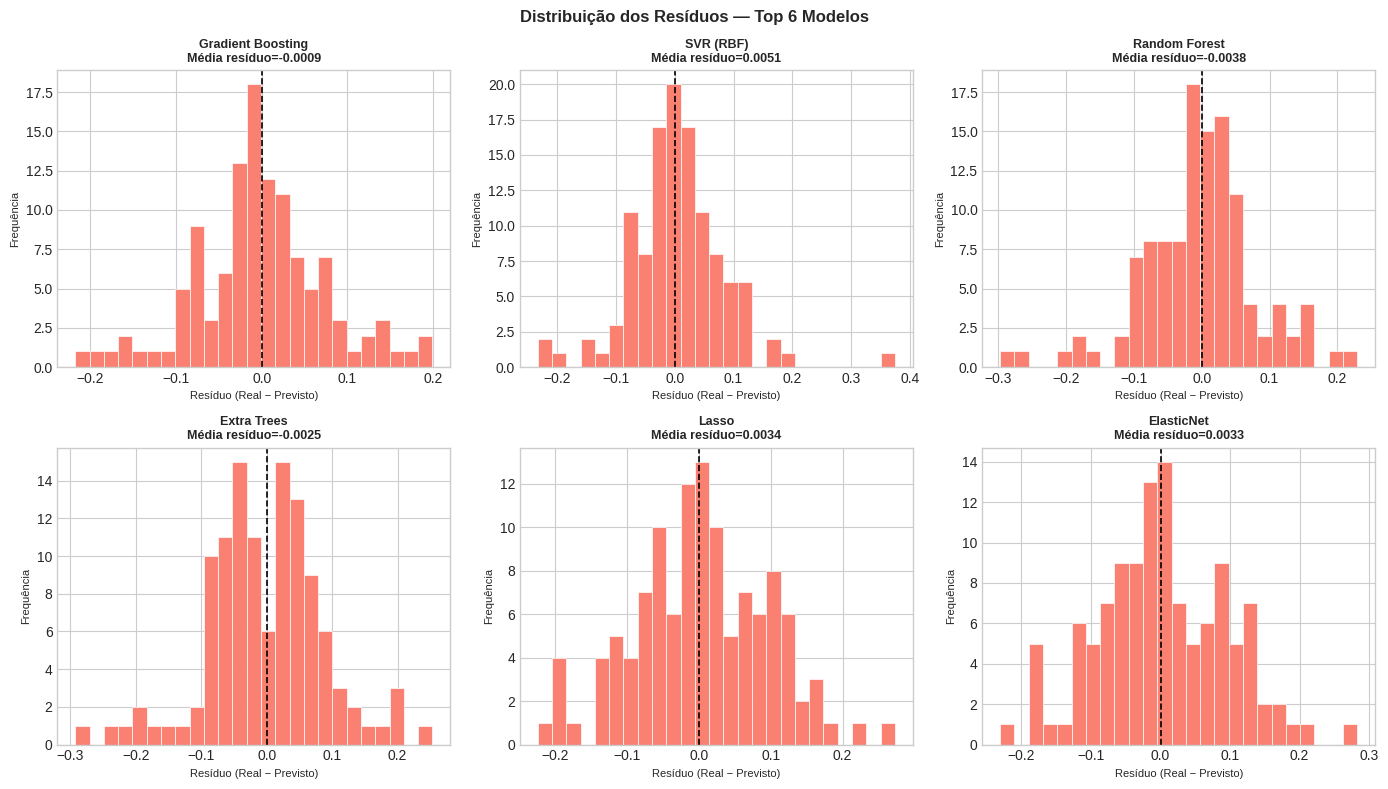

In [ ]:
# Distribuição dos resíduos — Top 6 modelos
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, model_name in enumerate(top_models):
    residuals = y_test_arr - predictions[model_name]
    axes[i].hist(residuals, bins=25, color='salmon', edgecolor='white', linewidth=0.5)
    axes[i].axvline(0, color='black', linewidth=1.2, linestyle='--')
    axes[i].set_title(f'{model_name}\nMédia resíduo={residuals.mean():.4f}',
                      fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Resíduo (Real − Previsto)', fontsize=8)
    axes[i].set_ylabel('Frequência', fontsize=8)

plt.suptitle('Distribuição dos Resíduos — Top 6 Modelos', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

---
## 6. Importância das Features (Modelos de Ensemble)

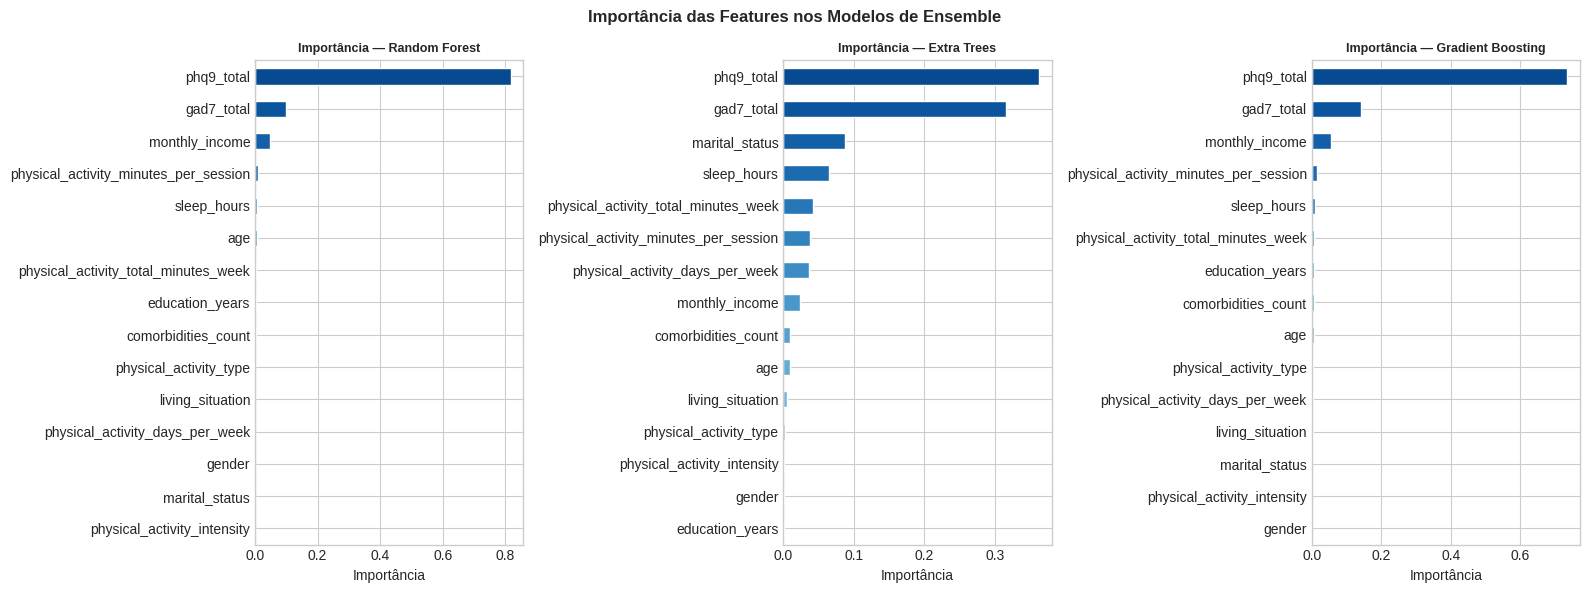

In [ ]:
# Importância das features — modelos com atributo feature_importances_
ensemble_models = {
    'Random Forest':      rf_pipe,
    'Extra Trees':        et_pipe,
    'Gradient Boosting':  gb_pipe,
}

feature_names = X.columns.tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, (name, pipe) in zip(axes, ensemble_models.items()):
    importances = pipe.named_steps['model'].feature_importances_
    feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)
    colors_imp = plt.cm.Blues(np.linspace(0.3, 0.9, len(feat_imp)))
    feat_imp.plot(kind='barh', ax=ax, color=colors_imp, edgecolor='white')
    ax.set_title(f'Importância — {name}', fontweight='bold', fontsize=9)
    ax.set_xlabel('Importância')

plt.suptitle('Importância das Features nos Modelos de Ensemble',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

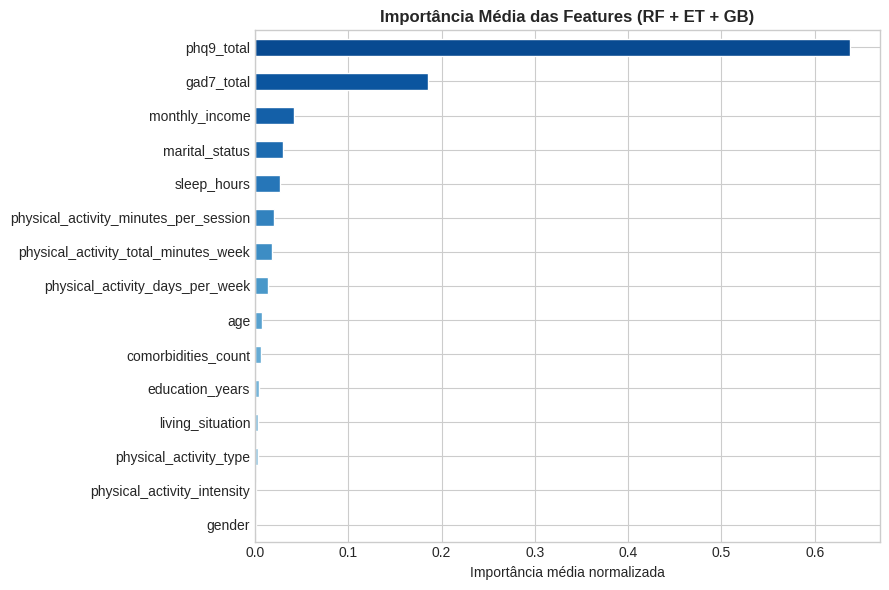


Ranking de Importância Média:
phq9_total                               0.6381
gad7_total                               0.1857
monthly_income                           0.0424
marital_status                           0.0297
sleep_hours                              0.0272
physical_activity_minutes_per_session    0.0202
physical_activity_total_minutes_week     0.0180
physical_activity_days_per_week          0.0138
age                                      0.0071
comorbidities_count                      0.0065
education_years                          0.0038
living_situation                         0.0030
physical_activity_type                   0.0030
physical_activity_intensity              0.0008
gender                                   0.0007


In [ ]:
# Importância média normalizada entre os 3 modelos de ensemble
all_importances = pd.DataFrame({
    name: pipe.named_steps['model'].feature_importances_
    for name, pipe in ensemble_models.items()
}, index=feature_names)

all_importances['Média'] = all_importances.mean(axis=1)
all_importances = all_importances.sort_values('Média', ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
colors_avg = plt.cm.Blues(np.linspace(0.9, 0.3, len(all_importances)))
all_importances['Média'].sort_values().plot(kind='barh', ax=ax, color=colors_avg[::-1],
                                             edgecolor='white')
ax.set_title('Importância Média das Features (RF + ET + GB)', fontweight='bold')
ax.set_xlabel('Importância média normalizada')
plt.tight_layout()
plt.show()

print('\nRanking de Importância Média:')
print(all_importances['Média'].sort_values(ascending=False).round(4).to_string())

---
## 7. Análise dos Coeficientes — Modelos Lineares

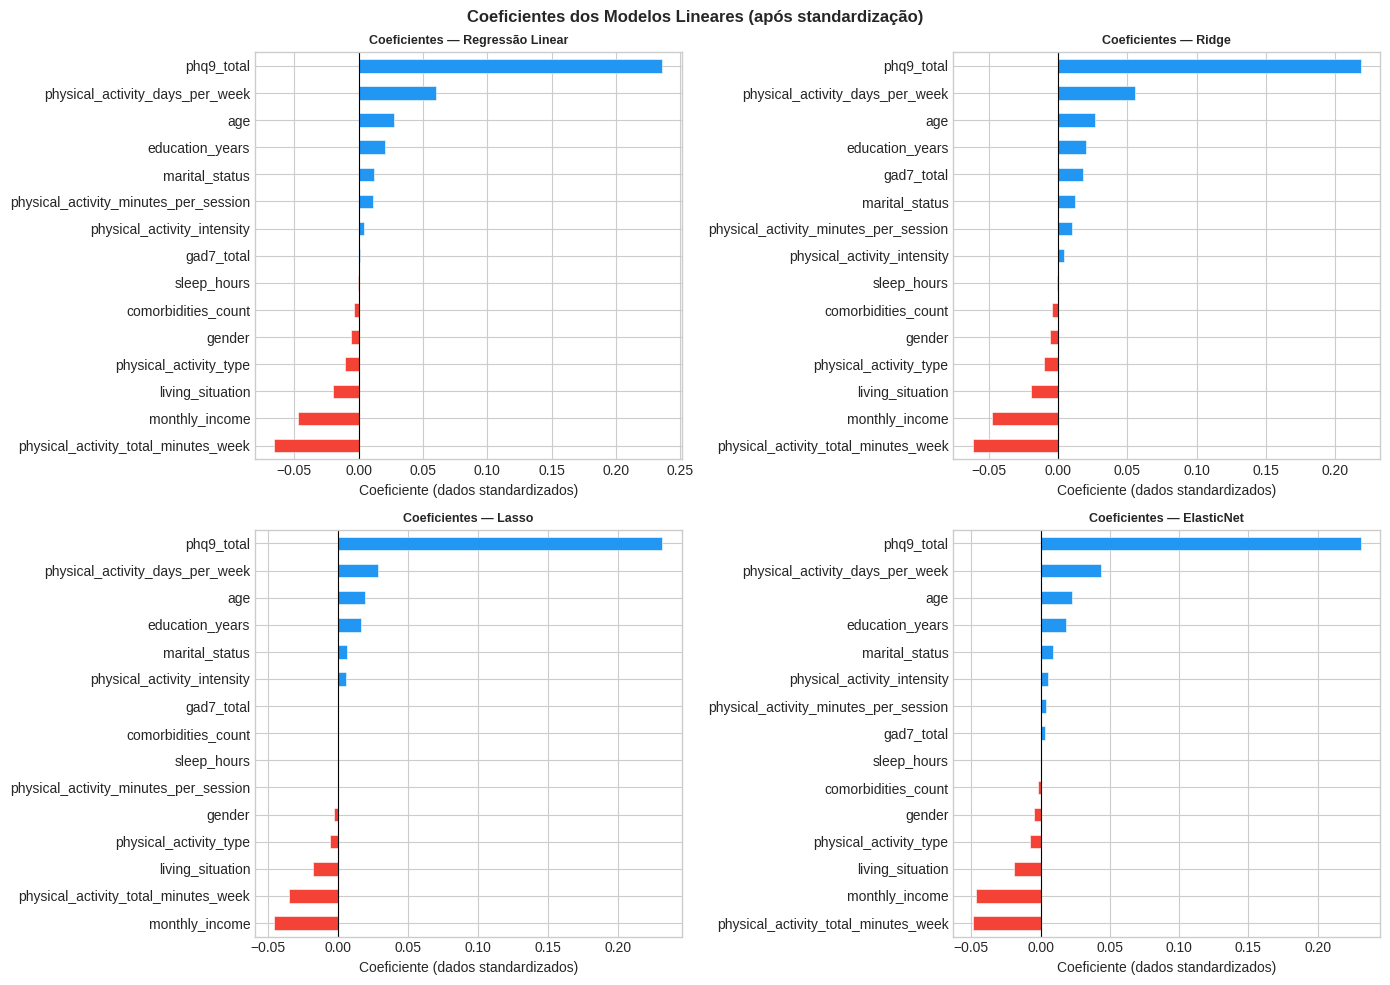

In [ ]:
linear_models = {
    'Regressão Linear': lr_pipe,
    'Ridge':            ridge_pipe,
    'Lasso':            lasso_pipe,
    'ElasticNet':       en_pipe,
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (name, pipe) in zip(axes, linear_models.items()):
    coefs = pd.Series(pipe.named_steps['model'].coef_, index=feature_names).sort_values()
    colors_coef = ['#F44336' if c < 0 else '#2196F3' for c in coefs]
    coefs.plot(kind='barh', ax=ax, color=colors_coef, edgecolor='white', linewidth=0.4)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Coeficientes — {name}', fontweight='bold', fontsize=9)
    ax.set_xlabel('Coeficiente (dados standardizados)')

plt.suptitle('Coeficientes dos Modelos Lineares (após standardização)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

---
## 8. Síntese dos Resultados

In [ ]:
# Tabela final resumida
final_table = results_df[['Teste R²', 'Teste MAE', 'Teste RMSE',
                           'CV R² (média)', 'CV R² (std)']].round(4)
final_table = final_table.sort_values('Teste R²', ascending=False)

print('=' * 70)
print('  RANKING FINAL — Conjunto de Teste')
print('=' * 70)
print(final_table.to_string())
print()

best_model = final_table.index[0]
best_r2    = final_table.loc[best_model, 'Teste R²']
best_mae   = final_table.loc[best_model, 'Teste MAE']

print(f'🏆 Melhor modelo:  {best_model}')
print(f'   Teste R²:  {best_r2:.4f}')
print(f'   Teste MAE: {best_mae:.4f}')
print()
print('Baseline (média ingénua):')
naive_mae = mean_absolute_error(y_test, np.full_like(y_test, y_train.mean()))
print(f'   MAE se prevermos sempre a média: {naive_mae:.4f}')

  RANKING FINAL — Conjunto de Teste
                   Teste R²  Teste MAE  Teste RMSE  CV R² (média)  CV R² (std)
Modelo                                                                        
Gradient Boosting    0.9069     0.0558      0.0756         0.9120       0.0156
SVR (RBF)            0.8931     0.0580      0.0810         0.9090       0.0159
Random Forest        0.8843     0.0608      0.0843         0.8966       0.0171
Extra Trees          0.8723     0.0682      0.0886         0.8936       0.0177
Lasso                0.8581     0.0735      0.0934         0.8858       0.0134
ElasticNet           0.8566     0.0738      0.0938         0.8860       0.0134
Ridge                0.8543     0.0742      0.0946         0.8851       0.0134
Regressão Linear     0.8541     0.0746      0.0947         0.8854       0.0132
MLP                  0.8477     0.0710      0.0967         0.8656       0.0254
Árvore de Decisão    0.8423     0.0791      0.0984         0.8561       0.0255
KNN             

---
## 9. Análise com Threshold — Conversão para Classificação Binária

Nesta secção, as previsões contínuas dos modelos de regressão já treinados são convertidas em classes binárias através de um threshold:

- **0** → sem perturbação mental (probabilidade < threshold)
- **1** → com perturbação mental (probabilidade ≥ threshold)

**Thresholds analisados:** 0.30, 0.40, 0.50, 0.60, 0.70

Na área clínica, é frequente usar thresholds mais baixos (ex: 0.30–0.40) para **maximizar a sensibilidade**, ou seja, preferir falsos positivos (sinalizar alguém saudável) a falsos negativos (não detetar alguém com perturbação).

In [ ]:
THRESHOLDS = [0.30, 0.40, 0.50, 0.60, 0.70]

# Ground truth binário para cada threshold
y_test_arr = y_test.values

print('✅ Métricas de classificação importadas.')
print(f'Modelos disponíveis: {list(predictions.keys())}')

✅ Métricas de classificação importadas.
Modelos disponíveis: ['Regressão Linear', 'Ridge', 'Lasso', 'ElasticNet', 'KNN', 'Árvore de Decisão', 'SVR (RBF)', 'Random Forest', 'Extra Trees', 'Gradient Boosting', 'MLP']


### 9.1 Métricas por Modelo e Threshold



No contexto clínico, existe sempre um **trade-off** entre sensibilidade e especificidade. Para compreender estas métricas, é necessário partir da **matriz de confusão**:

|  | **Previsto: Sem Perturbação** | **Previsto: Com Perturbação** |
|---|---|---|
| **Real: Sem Perturbação** | ✅ Verdadeiro Negativo (TN) | ❌ Falso Positivo (FP) |
| **Real: Com Perturbação** | ❌ Falso Negativo (FN) | ✅ Verdadeiro Positivo (TP) |

A partir desta matriz derivam-se as métricas principais:

| Métrica | Fórmula | Interpretação |
|---|---|---|
| **Sensibilidade** | TP / (TP + FN) | Dos que têm perturbação, quantos foram detetados? |
| **Especificidade** | TN / (TN + FP) | Dos que não têm perturbação, quantos foram corretamente identificados? |
| **F1-Score** | 2 × (Precisão × Sensibilidade) / (Precisão + Sensibilidade) | Equilíbrio entre precisão e sensibilidade |
| **AUC-ROC** | Área sob a curva ROC | Capacidade discriminativa global do modelo, independente do threshold |

> ⚠️ **Nota clínica:** No contexto da saúde mental, um **falso negativo** (não detetar alguém com perturbação) é geralmente mais grave do que um **falso positivo** (sinalizar alguém saudável). Por isso, pode ser preferível usar thresholds mais baixos (ex: 0.30–0.40) para **maximizar a sensibilidade**, mesmo que isso implique uma redução da especificidade.

In [ ]:
clf_results = []

for threshold in THRESHOLDS:
    y_true_bin = (y_test_arr >= threshold).astype(int)
    pos_rate = y_true_bin.mean()

    for model_name, y_pred_cont in predictions.items():
        y_pred_bin = (y_pred_cont >= threshold).astype(int)

        acc  = accuracy_score(y_true_bin, y_pred_bin)
        f1   = f1_score(y_true_bin, y_pred_bin, zero_division=0)
        # AUC usa as probabilidades contínuas (melhor estimativa)
        try:
            auc = roc_auc_score(y_true_bin, y_pred_cont)
        except Exception:
            auc = np.nan

        cm = confusion_matrix(y_true_bin, y_pred_bin)
        tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # recall / true positive rate
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

        clf_results.append({
            'Threshold': threshold,
            'Modelo': model_name,
            '% Positivos (real)': round(pos_rate * 100, 1),
            'Accuracy': acc,
            'F1-Score': f1,
            'AUC-ROC': auc,
            'Sensibilidade': sensitivity,
            'Especificidade': specificity,
        })

clf_df = pd.DataFrame(clf_results)
print(f'Total de combinações avaliadas: {len(clf_df)} ({len(predictions)} modelos × {len(THRESHOLDS)} thresholds)')

Total de combinações avaliadas: 55 (11 modelos × 5 thresholds)


In [ ]:
# Tabela completa — todas as métricas por modelo e threshold
for metric in ['F1-Score', 'AUC-ROC', 'Sensibilidade', 'Especificidade', 'Accuracy']:
    pivot = clf_df.pivot(index='Modelo', columns='Threshold', values=metric).round(3)
    pivot.columns = [f'thr={c}' for c in pivot.columns]

    display(pivot.style
        .background_gradient(cmap='RdYlGn', axis=None)
        .format('{:.3f}')
        .set_caption(f'{metric} por Modelo e Threshold'))
    print()

,thr=0.3,thr=0.4,thr=0.5,thr=0.6,thr=0.7
Modelo,,,,,
ElasticNet,0.907,0.918,0.889,0.812,0.727
Extra Trees,0.907,0.912,0.913,0.886,0.800
Gradient Boosting,0.924,0.935,0.913,0.882,0.894
KNN,0.894,0.821,0.814,0.848,0.851
Lasso,0.912,0.918,0.889,0.825,0.727
MLP,0.907,0.887,0.876,0.853,0.809
Random Forest,0.918,0.911,0.913,0.873,0.844
Regressão Linear,0.908,0.918,0.889,0.812,0.756
Ridge,0.914,0.918,0.889,0.812,0.756


,thr=0.3,thr=0.4,thr=0.5,thr=0.6,thr=0.7
Modelo,,,,,
ElasticNet,0.949,0.968,0.978,0.978,0.973
Extra Trees,0.934,0.958,0.976,0.986,0.980
Gradient Boosting,0.955,0.973,0.985,0.985,0.980
KNN,0.903,0.918,0.930,0.953,0.949
Lasso,0.949,0.969,0.977,0.979,0.975
MLP,0.953,0.964,0.959,0.979,0.970
Random Forest,0.939,0.966,0.982,0.986,0.978
Regressão Linear,0.949,0.969,0.977,0.976,0.971
Ridge,0.950,0.970,0.977,0.976,0.972


,thr=0.3,thr=0.4,thr=0.5,thr=0.6,thr=0.7
Modelo,,,,,
ElasticNet,0.912,0.875,0.870,0.743,0.640
Extra Trees,0.912,0.891,0.913,0.886,0.720
Gradient Boosting,0.912,0.906,0.913,0.857,0.840
KNN,0.900,0.750,0.761,0.800,0.800
Lasso,0.912,0.875,0.870,0.743,0.640
MLP,0.912,0.859,0.848,0.829,0.760
Random Forest,0.912,0.875,0.913,0.886,0.760
Regressão Linear,0.925,0.875,0.870,0.743,0.680
Ridge,0.925,0.875,0.870,0.743,0.680


,thr=0.3,thr=0.4,thr=0.5,thr=0.6,thr=0.7
Modelo,,,,,
ElasticNet,0.784,0.962,0.944,0.963,0.967
Extra Trees,0.784,0.925,0.944,0.951,0.978
Gradient Boosting,0.865,0.962,0.944,0.963,0.989
KNN,0.757,0.906,0.930,0.963,0.978
Lasso,0.811,0.962,0.944,0.976,0.967
MLP,0.784,0.906,0.944,0.951,0.967
Random Forest,0.838,0.943,0.944,0.939,0.989
Regressão Linear,0.757,0.962,0.944,0.963,0.967
Ridge,0.784,0.962,0.944,0.963,0.967


,thr=0.3,thr=0.4,thr=0.5,thr=0.6,thr=0.7
Modelo,,,,,
ElasticNet,0.872,0.915,0.915,0.897,0.897
Extra Trees,0.872,0.906,0.932,0.932,0.923
Gradient Boosting,0.897,0.932,0.932,0.932,0.957
KNN,0.855,0.821,0.863,0.915,0.940
Lasso,0.880,0.915,0.915,0.906,0.897
MLP,0.872,0.880,0.906,0.915,0.923
Random Forest,0.889,0.906,0.932,0.923,0.940
Regressão Linear,0.872,0.915,0.915,0.897,0.906
Ridge,0.880,0.915,0.915,0.897,0.906


### 9.2 Curvas ROC — Todos os Modelos

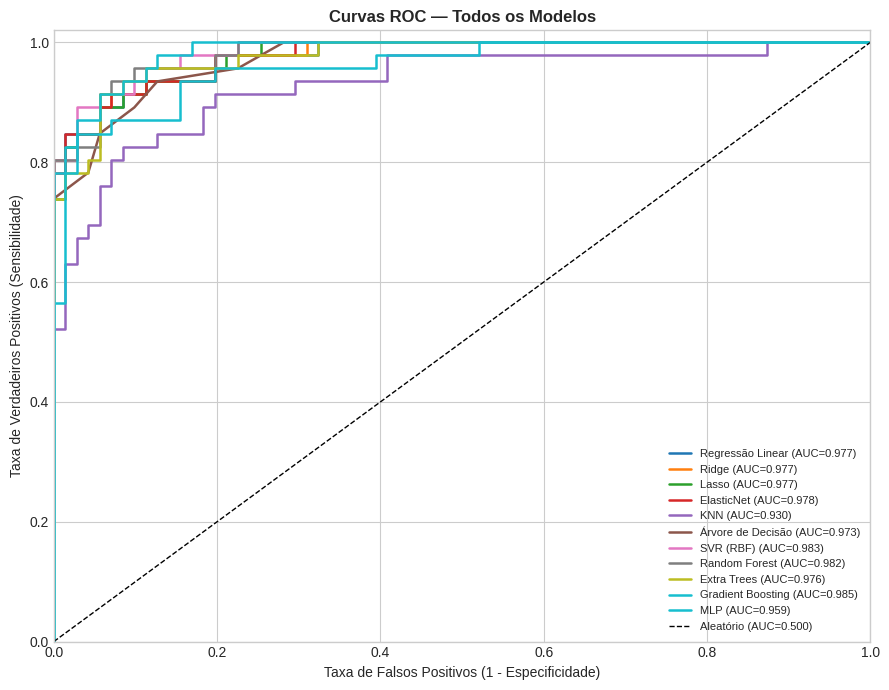

In [ ]:
# Curvas ROC com threshold = 0.50 como referência
y_true_bin = (y_test_arr >= 0.50).astype(int)

fig, ax = plt.subplots(figsize=(9, 7))

colors_roc = plt.cm.tab10(np.linspace(0, 1, len(predictions)))

for (model_name, y_pred_cont), color in zip(predictions.items(), colors_roc):
    try:
        fpr, tpr, _ = roc_curve(y_true_bin, y_pred_cont)
        auc_val = roc_auc_score(y_true_bin, y_pred_cont)
        ax.plot(fpr, tpr, color=color, linewidth=1.8,
                label=f'{model_name} (AUC={auc_val:.3f})')
    except Exception:
        pass

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatório (AUC=0.500)')
ax.set_xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
ax.set_ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)')
ax.set_title('Curvas ROC — Todos os Modelos',
             fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.show()

### 9.3 Melhor Threshold por Modelo

Para cada modelo, identificamos o threshold que maximiza o F1-Score.

In [ ]:
best_threshold_per_model = (
    clf_df.loc[clf_df.groupby('Modelo')['F1-Score'].idxmax()]
    [['Modelo', 'Threshold', 'F1-Score', 'AUC-ROC', 'Sensibilidade', 'Especificidade', 'Accuracy']]
    .set_index('Modelo')
    .sort_values('F1-Score', ascending=False)
)

display(best_threshold_per_model.round(3).style
    .background_gradient(subset=['F1-Score'], cmap='RdYlGn')
    .background_gradient(subset=['AUC-ROC'], cmap='RdYlGn')
    .background_gradient(subset=['Threshold'], cmap='YlOrRd')
    .format('{:.3f}', subset=['F1-Score','AUC-ROC','Sensibilidade','Especificidade','Accuracy'])
    .set_caption('Melhor Threshold por Modelo (maximizando F1-Score)'))

best_overall = best_threshold_per_model.sort_values(
    ['F1-Score', 'AUC-ROC', 'Sensibilidade', 'Especificidade', 'Accuracy'], ascending=False
).index[0]
best_thr     = best_threshold_per_model.loc[best_overall, 'Threshold']
best_f1      = best_threshold_per_model.loc[best_overall, 'F1-Score']
best_auc     = best_threshold_per_model.loc[best_overall, 'AUC-ROC']
best_sens    = best_threshold_per_model.loc[best_overall, 'Sensibilidade']
best_spec    = best_threshold_per_model.loc[best_overall, 'Especificidade']
best_acc     = best_threshold_per_model.loc[best_overall, 'Accuracy']

print(f'\n🏆 Melhor combinação:')
print(f'   Modelo:         {best_overall}')
print(f'   Threshold:      {best_thr}')
print(f'   F1-Score:       {best_f1:.3f}')
print(f'   AUC-ROC:        {best_auc:.3f}')
print(f'   Sensibilidade:  {best_sens:.3f}')
print(f'   Especificidade: {best_spec:.3f}')
print(f'   Accuracy:       {best_acc:.3f}')

,Threshold,F1-Score,AUC-ROC,Sensibilidade,Especificidade,Accuracy
Modelo,,,,,,
Gradient Boosting,0.400000,0.935,0.973,0.906,0.962,0.932
SVR (RBF),0.400000,0.935,0.986,0.906,0.962,0.932
Random Forest,0.300000,0.918,0.939,0.912,0.838,0.889
Ridge,0.400000,0.918,0.970,0.875,0.962,0.915
ElasticNet,0.400000,0.918,0.968,0.875,0.962,0.915
Regressão Linear,0.400000,0.918,0.969,0.875,0.962,0.915
Lasso,0.400000,0.918,0.969,0.875,0.962,0.915
Extra Trees,0.500000,0.913,0.976,0.913,0.944,0.932
Árvore de Decisão,0.400000,0.908,0.953,0.922,0.868,0.897



🏆 Melhor combinação:
   Modelo:         SVR (RBF)
   Threshold:      0.4
   F1-Score:       0.935
   AUC-ROC:        0.986
   Sensibilidade:  0.906
   Especificidade: 0.962
   Accuracy:       0.932


### 9.4 Matriz Confusão e Curva ROC do Melhor Modelo no seu Threshold Ótimo

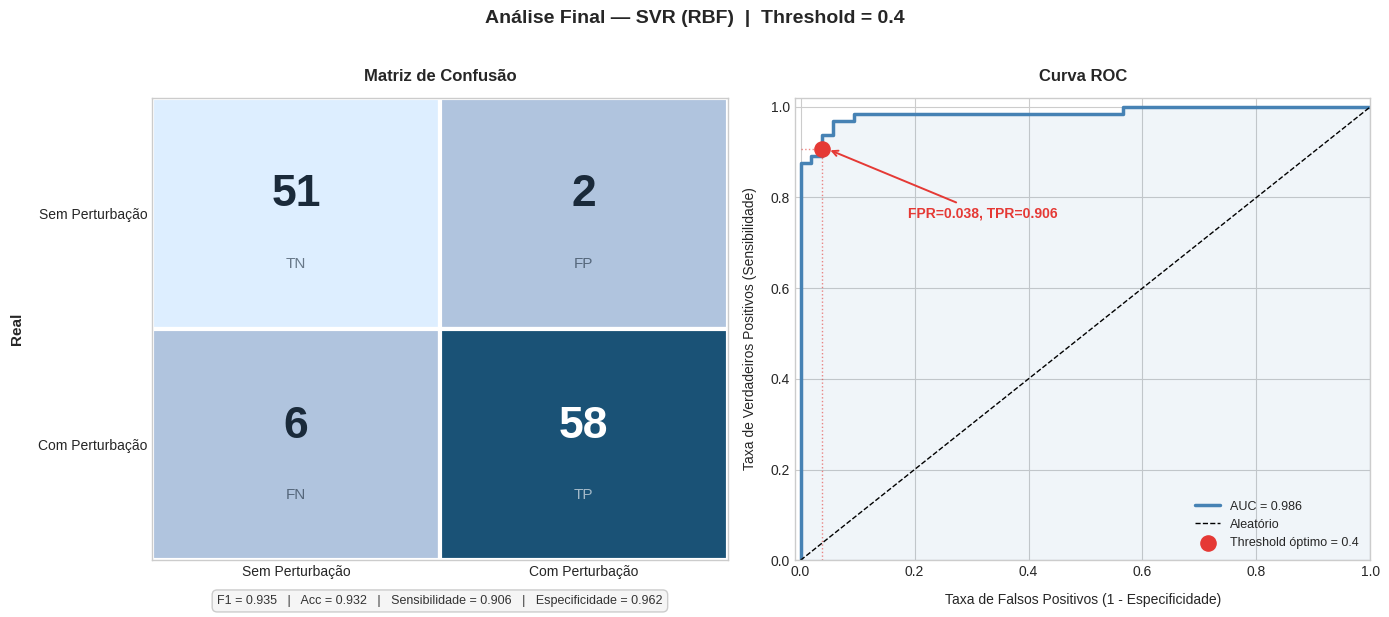

In [ ]:
# Matriz de confusão + Curva ROC — melhor modelo no seu threshold ótimo
best_thr_value = best_threshold_per_model.loc[best_overall, 'Threshold']
y_true_bin = (y_test_arr >= best_thr_value).astype(int)
y_pred_bin = (predictions[best_overall] >= best_thr_value).astype(int)

cm = confusion_matrix(y_true_bin, y_pred_bin)
tn, fp, fn, tp = cm.ravel()

f1   = f1_score(y_true_bin, y_pred_bin, zero_division=0)
acc  = accuracy_score(y_true_bin, y_pred_bin)
sens = tp / (tp + fn)
spec = tn / (tn + fp)

fig = plt.figure(figsize=(14, 6))
fig.suptitle(f'Análise Final — {best_overall}  |  Threshold = {best_thr_value}',
             fontweight='bold', fontsize=14, y=1.02)

# ── Matriz de confusão ──────────────────────────────────────────
ax1 = fig.add_subplot(1, 2, 1)

colors_cm = ['#DDEEFF', '#B0C4DE', '#4A90D9', '#1A5276']
cell_colors = [[colors_cm[0], colors_cm[1]],
               [colors_cm[1], colors_cm[3]]]

for i in range(2):
    for j in range(2):
        ax1.add_patch(plt.Rectangle((j, 1-i), 1, 1,
                                     facecolor=cell_colors[i][j], edgecolor='white', linewidth=3))
        val = cm[i, j]
        text_color = 'white' if (i == 1 and j == 1) else '#1A2A3A'
        ax1.text(j + 0.5, 1 - i + 0.58, str(val),
                 ha='center', va='center', fontsize=32, fontweight='bold', color=text_color)
        cell_label = [['TN', 'FP'], ['FN', 'TP']][i][j]
        ax1.text(j + 0.5, 1 - i + 0.28, cell_label,
                 ha='center', va='center', fontsize=11, color=text_color, alpha=0.6)

ax1.set_xlim(0, 2)
ax1.set_ylim(0, 2)
ax1.set_xticks([0.5, 1.5])
ax1.set_yticks([0.5, 1.5])
ax1.set_xticklabels(['Sem Perturbação', 'Com Perturbação'], fontsize=10)
ax1.set_yticklabels(['Com Perturbação', 'Sem Perturbação'], fontsize=10)
ax1.set_xlabel('Previsto', fontsize=11, fontweight='bold', labelpad=10)
ax1.set_ylabel('Real', fontsize=11, fontweight='bold', labelpad=10)
ax1.set_title('Matriz de Confusão', fontweight='bold', fontsize=12, pad=12)
ax1.tick_params(length=0)

# Métricas em caixa separada abaixo
metrics_text = f'F1 = {f1:.3f}   |   Acc = {acc:.3f}   |   Sensibilidade = {sens:.3f}   |   Especificidade = {spec:.3f}'
ax1.text(1, -0.15, metrics_text, ha='center', va='top',
         fontsize=9, color='#333333', transform=ax1.transData,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#F5F5F5', edgecolor='#CCCCCC'))

# ── Curva ROC ───────────────────────────────────────────────────
ax2 = fig.add_subplot(1, 2, 2)

fpr, tpr, _ = roc_curve(y_true_bin, predictions[best_overall])
auc_val = roc_auc_score(y_true_bin, predictions[best_overall])

ax2.plot(fpr, tpr, color='steelblue', linewidth=2.5, label=f'AUC = {auc_val:.3f}')
ax2.fill_between(fpr, tpr, alpha=0.08, color='steelblue')
ax2.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatório')

# Ponto óptimo
opt_fpr = 1 - spec
opt_tpr = sens
ax2.scatter(opt_fpr, opt_tpr, color='#E53935', s=120, zorder=5,
            label=f'Threshold óptimo = {best_thr_value}')

# Linhas tracejadas até aos eixos
ax2.plot([opt_fpr, opt_fpr], [0, opt_tpr], color='#E53935', linewidth=1,
         linestyle=':', alpha=0.6)
ax2.plot([0, opt_fpr], [opt_tpr, opt_tpr], color='#E53935', linewidth=1,
         linestyle=':', alpha=0.6)

# Anotação fora da curva
ax2.annotate(f'FPR={opt_fpr:.3f}, TPR={opt_tpr:.3f}',
             xy=(opt_fpr + 0.01, opt_tpr),
             xytext=(opt_fpr + 0.15, opt_tpr - 0.15),
             fontsize=10, fontweight='bold', color='#E53935',
             arrowprops=dict(arrowstyle='->', color='#E53935', lw=1.4))

ax2.set_xlabel('Taxa de Falsos Positivos (1 - Especificidade)', fontsize=10, labelpad=10)
ax2.set_ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)', fontsize=10, labelpad=10)
ax2.set_title('Curva ROC', fontweight='bold', fontsize=12, pad=12)
ax2.legend(fontsize=9, loc='lower right')
ax2.set_xlim(-0.01, 1)
ax2.set_ylim(0, 1.02)

plt.tight_layout()
plt.show()